# 🎨 Part 4: Best Model Training & Sample Generation (15%)
**SVG Scaling Laws Project** — NYU CS-GY 6923

This notebook:
1. Loads the best trained model
2. Generates unconditional SVG samples
3. Generates prefix-conditioned completions
4. Evaluates: perplexity, XML validity, render rate
5. Creates visualizations for the report

## 4.1 Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, yaml, json, torch
BASE_DIR = "/content/drive/MyDrive/svg-scaling"
PROJECT_DIR = "/content/drive/MyDrive/svg-scaling-laws"
sys.path.insert(0, PROJECT_DIR)

!pip install -q datasets tokenizers lxml cairosvg mup wandb scipy seaborn tqdm pyyaml

with open(os.path.join(PROJECT_DIR, "configs", "model_configs.yaml")) as f:
    model_configs = yaml.safe_load(f)
with open(os.path.join(PROJECT_DIR, "configs", "training_config.yaml")) as f:
    train_config = yaml.safe_load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 8.7 MB/s eta 0:00:00
Device: cuda


## 4.2 Load Best Model

In [2]:
# Load the best checkpoint (try µP XL first, then SP XL)
from model.transformer import GPT
from model.transformer_mup import MuPGPT
from data.train_tokenizer import load_tokenizer

CKPT_DIR = train_config["checkpoint_dir"]
TOKENIZER_DIR = train_config["tokenizer_dir"]

# Try loading best checkpoint
model = None
for prefix, ModelClass in [("sp_xl", GPT), ("mup_xl", MuPGPT),
                           ("sp_large", GPT), ("mup_large", MuPGPT)]:
    ckpt_path = os.path.join(CKPT_DIR, prefix, "best.pt")
    if os.path.exists(ckpt_path):
        print(f"Loading checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model = ModelClass.from_config_dict(
            ckpt["config"],
            vocab_size=train_config["vocab_size"],
            block_size=train_config["block_size"],
        )
        model.load_state_dict(ckpt["model"])
        model = model.to(device)
        model.eval()
        print(f" Loaded {prefix} (val_loss={ckpt.get('val_loss', 'N/A')})")
        print(f"   Params: {model.count_parameters():,}")
        break

if model is None:
    print(" No checkpoint found! Train models first.")

# Load tokenizer
tokenizer = load_tokenizer(TOKENIZER_DIR)
print(f"Tokenizer vocab: {tokenizer.get_vocab_size()}")

Loading checkpoint: /content/drive/MyDrive/svg-scaling/checkpoints/sp_xl/best.pt
 Loaded sp_xl (val_loss=0.6831948947906494)
   Params: 88,099,584
Tokenizer vocab: 4096


## 4.3 Generate Unconditional Samples

In [3]:
from generation.generate import generate_unconditional
import importlib
from evaluation import render_svg
importlib.reload(render_svg)
from evaluation.render_svg import create_sample_grid
GEN_DIR = os.path.join(BASE_DIR, "results", "generation")
os.makedirs(GEN_DIR, exist_ok=True)

# Generate 12 unconditional samples
unconditional_samples = generate_unconditional(
    model, tokenizer,
    num_samples=12,
    max_tokens=4000,
    temperature=0.7,
    top_p=0.9,
    device=device,
)

# Save SVG files
for i, svg in enumerate(unconditional_samples):
    with open(os.path.join(GEN_DIR, f"unconditional_{i:02d}.svg"), "w") as f:
        f.write(svg)

  Sample 1/12: 4002 tokens, 8151 chars
  Sample 2/12: 4002 tokens, 12198 chars
  Sample 3/12: 4002 tokens, 9819 chars
  Sample 4/12: 4002 tokens, 10944 chars
  Sample 5/12: 4002 tokens, 9878 chars
  Sample 6/12: 4002 tokens, 9720 chars
  Sample 7/12: 4002 tokens, 10090 chars
  Sample 8/12: 3418 tokens, 9222 chars
  Sample 9/12: 4002 tokens, 10320 chars
  Sample 10/12: 1295 tokens, 2957 chars
  Sample 11/12: 4002 tokens, 10113 chars
  Sample 12/12: 4002 tokens, 10039 chars


Saved sample grid: /content/drive/MyDrive/svg-scaling/results/generation/unconditional_grid.png


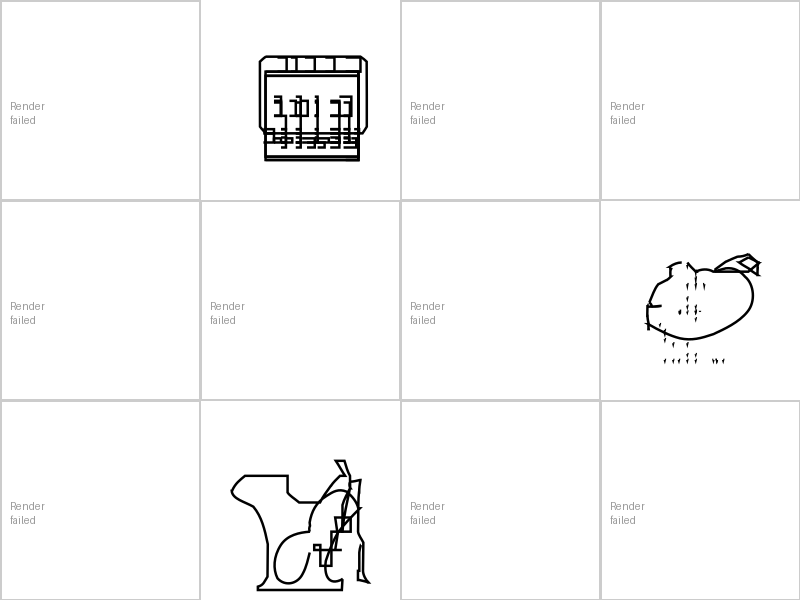

In [4]:
# Render and display grid
from evaluation.render_svg import create_sample_grid

create_sample_grid(
    unconditional_samples,
    os.path.join(GEN_DIR, "unconditional_grid.png"),
    cols=4, cell_size=200,
)

from IPython.display import Image, display
display(Image(os.path.join(GEN_DIR, "unconditional_grid.png"), width=800))

In [6]:
print(unconditional_samples[0])

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1" filling="0" d="M9.46875 4.5 L9.46875 4.5 C10.96174583435059 4.8 12.1 4.8 13.2 5.7 C14.69085578918457 6.6 15.3 8.2 15.3 10.2 C15.271977233886719 11.8 14.7 13.3 13.6 14.8 C12.614815440368652 16.1 11.4 17.2 9.5 17.2 C7.859227828979492 17.2 6.5 16.1 5.7 14.8 C4.896783847045898 13.3 4.5 11.8 4.5 10.2 C4.435897483825684 8.2 5.0 6.6 6.3 5.7 C7.284439697265625 4.9 8.4 4.8 9.5 4.5 L9.46875 4.5"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1" filling="0" d="M9.46875 4.8 L9.46875 4.8 C10.810722351074219 4.9 11.8 5.1 12.8 5.7 C14.227305221557617 6.5 15.0 7.8 15.2 9.4 C15.552286682128906 11.1 15.3 12.9 14.5 14.4 C13.614815521240234 16.0 12.1 17.1 9.5 17.1 C7.341904678344727 17.1 5.6 16.0 4.8 14.4 C4.191783149719238 12.9 4.4 11.1 4.7 9.4 C5.056109848022461 7.8 6.0 6.5 7.0 5.7 C8.231359481811523 5.1 8.8 4.9 9.5 4.8

## 4.4 Prefix-Conditioned Generation

In [5]:
from generation.generate import generate_prefix_conditioned
import importlib
from evaluation import render_svg
importlib.reload(render_svg)
from evaluation.render_svg import create_prefix_comparison
prefix_results = generate_prefix_conditioned(
    model, tokenizer,
    max_tokens=4000,
    temperature=0.7,
    top_p=0.9,
    top_k=50,
    device=device,
)

# Display results
for name, result in prefix_results.items():
    print(f"\n--- {name} ---")
    print(f"Prefix: {result['prefix'][:100]}...")
    print(f"Completion: {result['completion'][:200]}...")


  Generating from prefix: empty_svg
    2764 tokens, completion length: 6649 chars

  Generating from prefix: partial_face
    4095 tokens, completion length: 10016 chars

  Generating from prefix: open_path
    4057 tokens, completion length: 9271 chars

  Generating from prefix: group_one_shape
    4077 tokens, completion length: 9918 chars

  Generating from prefix: star_start
    4041 tokens, completion length: 9069 chars

--- empty_svg ---
Prefix: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24">...
Completion: 
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1" filling="0" d="M5.334375381469727 7.3 L5.334375381469727 7.3 C5.700000286102295 7.3 6.2 7.3 6.5 7.4 L6.515625 7.4"></path>
<path ...

--- partial_face ---
Prefix: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24">
<circle cx="12" cy="12" r="10" fill="no...
Completion: 
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1" filling="0" d="M13.012499809265137 6.8 L13.01

Saved prefix comparison: /content/drive/MyDrive/svg-scaling/results/generation/prefix_comparison.png


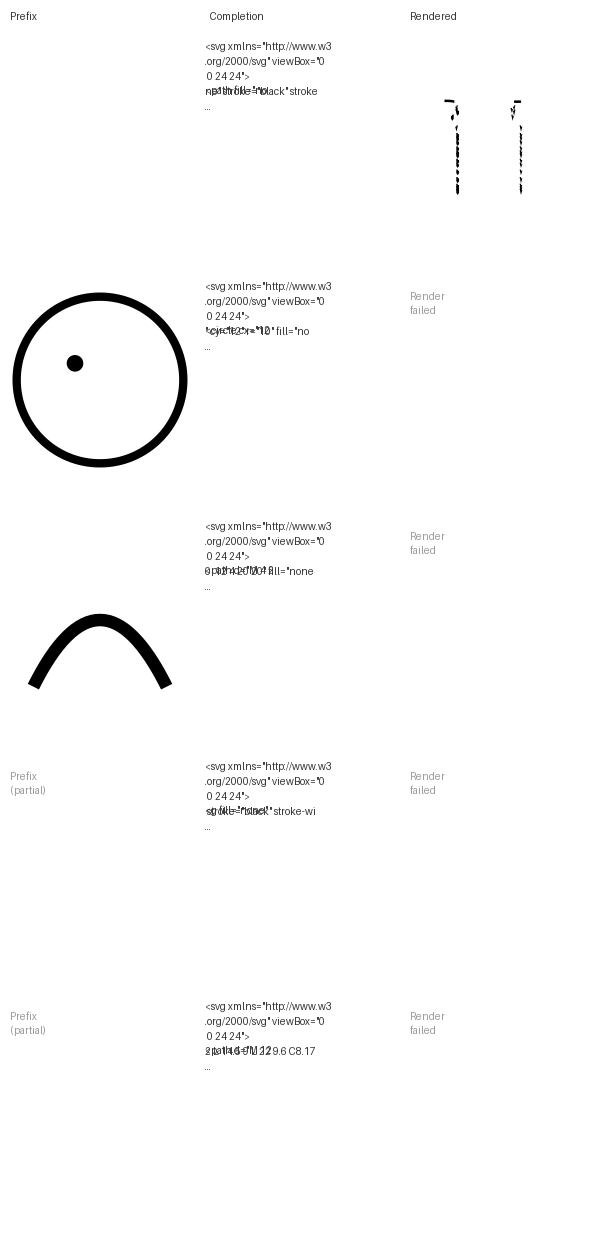

In [7]:
# Render prefix completions
from evaluation.render_svg import create_prefix_comparison

prefixes = [r["prefix"] for r in prefix_results.values()]
completions = [r["full"] for r in prefix_results.values()]

create_prefix_comparison(
    prefixes, completions,
    os.path.join(GEN_DIR, "prefix_comparison.png"),
)
display(Image(os.path.join(GEN_DIR, "prefix_comparison.png"), width=700))

## 4.5 Multi-Temperature Comparison


  Temperature: 0.5
  Sample 1/4: 4002 tokens, 9454 chars
  Sample 2/4: 4002 tokens, 10031 chars
  Sample 3/4: 4002 tokens, 9692 chars
  Sample 4/4: 4002 tokens, 10363 chars

  Temperature: 0.8
  Sample 1/4: 605 tokens, 1327 chars
  Sample 2/4: 2828 tokens, 6240 chars
  Sample 3/4: 4002 tokens, 9704 chars
  Sample 4/4: 557 tokens, 1181 chars

  Temperature: 1.0
  Sample 1/4: 221 tokens, 543 chars
  Sample 2/4: 1292 tokens, 3507 chars
  Sample 3/4: 664 tokens, 1332 chars
  Sample 4/4: 1189 tokens, 2472 chars
Saved sample grid: /content/drive/MyDrive/svg-scaling/results/generation/temp_0.5_grid.png

Temperature 0.5:


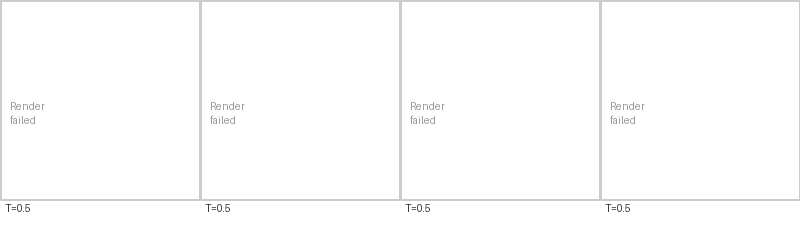

Saved sample grid: /content/drive/MyDrive/svg-scaling/results/generation/temp_0.8_grid.png

Temperature 0.8:


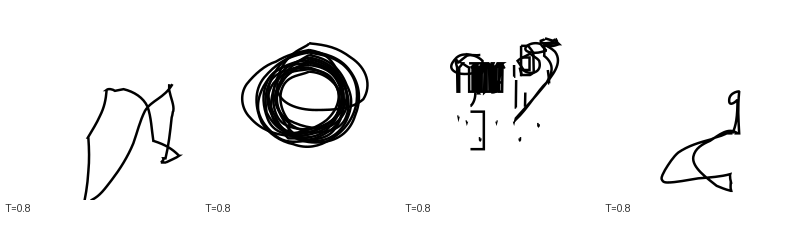

Saved sample grid: /content/drive/MyDrive/svg-scaling/results/generation/temp_1.0_grid.png

Temperature 1.0:


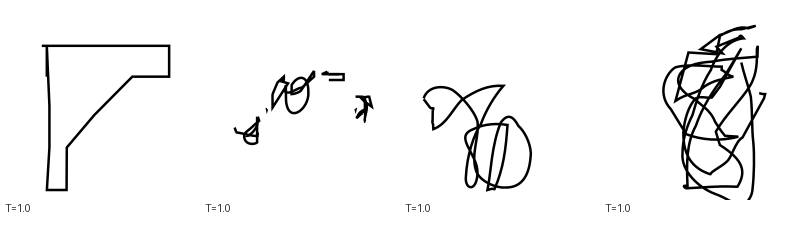

In [8]:
from generation.generate import generate_multi_temperature

temp_results = generate_multi_temperature(
    model, tokenizer,
    temperatures=[0.5, 0.8, 1.0],
    num_per_temp=4,
    max_tokens=4000,
    device=device,
)

# Render grid per temperature
for temp, samples in temp_results.items():
    create_sample_grid(
        samples,
        os.path.join(GEN_DIR, f"temp_{temp}_grid.png"),
        cols=4, cell_size=200,
        labels=[f"T={temp}"]*len(samples),
    )
    print(f"\nTemperature {temp}:")
    display(Image(os.path.join(GEN_DIR, f"temp_{temp}_grid.png"), width=800))

## 4.6 Quantitative Evaluation

In [9]:
from evaluation.evaluate import full_evaluation

EVAL_DIR = os.path.join(BASE_DIR, "results", "evaluation")
test_path = os.path.join(train_config["data_dir"], "test.bin")

# Combine all generated samples for evaluation
all_generated = unconditional_samples.copy()
for r in prefix_results.values():
    all_generated.append(r["full"])

metrics = full_evaluation(
    model, test_path, all_generated,
    output_dir=EVAL_DIR,
    block_size=train_config["block_size"],
    device=device,
)

print("\n Final Metrics:")
print(json.dumps({k: v for k, v in metrics.items()
                   if k not in ("validity",)}, indent=2))

Computing test set perplexity...


Computing perplexity:   0%|          | 0/78 [00:00<?, ?it/s]/content/drive/MyDrive/svg-scaling-laws/evaluation/evaluate.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):
Computing perplexity: 100%|██████████| 78/78 [00:02<00:00, 26.80it/s]


  Test perplexity: 2.03
  Test loss:       0.7105

Evaluating 17 generated SVGs

1. Checking validity...
  XML valid:         4/17 (23.5%)
  SVG root:          4/17 (23.5%)
  Closed tags:       4/17 (23.5%)
  Valid attributes:  4/17 (23.5%)
  Structurally valid:4/17 (23.5%)

2. Rendering SVGs...
Rendered 4/17 SVGs successfully
  Render success:    4/17 (23.5%)

Results saved to /content/drive/MyDrive/svg-scaling/results/evaluation

Evaluation Summary
  Test Perplexity:       2.03
  XML Validity Rate:     23.5%
  SVG Render Rate:       23.5%
  Structural Valid Rate: 23.5%

 Final Metrics:
{
  "test_perplexity": 2.0349109744152285,
  "test_loss": 0.710452070721517,
  "total_samples": 17,
  "render_rate": 0.23529411764705882,
  "render_success": 4,
  "length_stats": {
    "mean": 9354.64705882353,
    "median": 9878.0,
    "min": 2957,
    "max": 12198
  }
}
